In [1]:
import numpy as np
import librosa
from IPython.display import Audio
import matplotlib.pylab as plt
from matplotlib.ticker import FuncFormatter, NullFormatter



The following track will be used to analyse the convolution experiment.

In [2]:
wav_path = 'resources/drum-sample-full.wav'

y,sr = librosa.load(wav_path, sr=48000)

Audio(wav_path)

In [3]:
print("Number of samples", len(y))
print("Length", len(y)/sr, "seconds")
print("Max amplitude", np.max(y))

Number of samples 192000
Length 4.0 seconds
Max amplitude 0.43257117


# Kernal Signal 1
440Hz sine wave for 2 seconds with the same sampling rate

In [4]:
import numpy as np
from IPython.display import Audio

sr = 44100          # sample rate (Hz)
duration = 2.0      # seconds
freq = 440.0        # Hz (A4)

t = np.linspace(0, duration, int(sr * duration), endpoint=False)
sine = np.sin(2 * np.pi * freq * t)

Audio(sine, rate=sr)

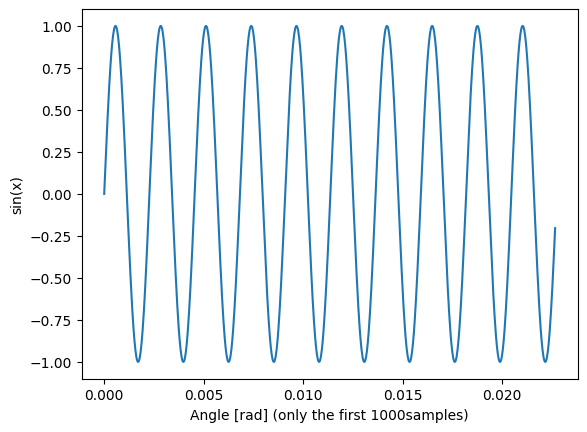

In [5]:
plt.plot(t[:1000], sine[:1000])
plt.xlabel('Angle [rad] (only the first 1000samples)')
plt.ylabel('sin(x)')
plt.axis('tight')
plt.show()

Here are the parameters of the above sine wave

In [6]:
print("Number of samples", len(sine))
print("Length", len(sine)/sr, "seconds")
print("Max amplitude", np.max(sine))

Number of samples 88200
Length 2.0 seconds
Max amplitude 0.9999997462578873


In [7]:
c = np.convolve(y, sine, mode='same')

Audio(c, rate=sr)

The output signal mainly holds charateristics of the kernal signal and the original signal is concealed.

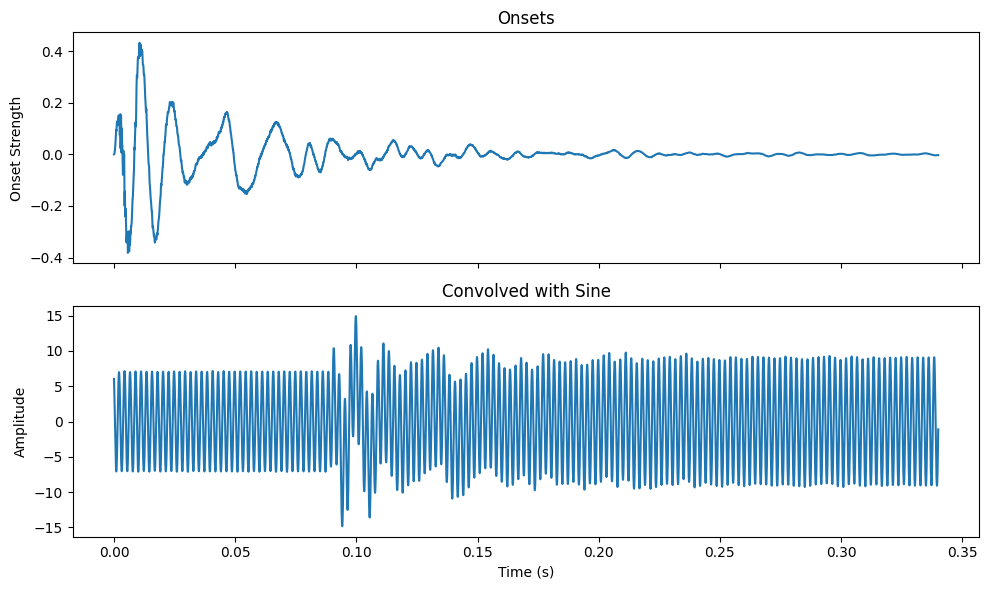

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

n_samples = 15000

ax1.plot(np.arange(n_samples) / sr, y[:n_samples])
ax1.set_ylabel("Onset Strength")
ax1.set_title("Onsets")

ax2.plot(np.arange(n_samples) / sr, c[:n_samples])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Convolved with Sine")

plt.tight_layout()
plt.show()


The closer look of the wave shows that the amplitudes are smoothened with having differences peaks.

In [9]:
print("Number of samples", len(c))
print("Length", len(c)/sr, "seconds")
print("Max amplitude", np.max(c))

Number of samples 192000
Length 4.35374149659864 seconds
Max amplitude 20.288598996176795


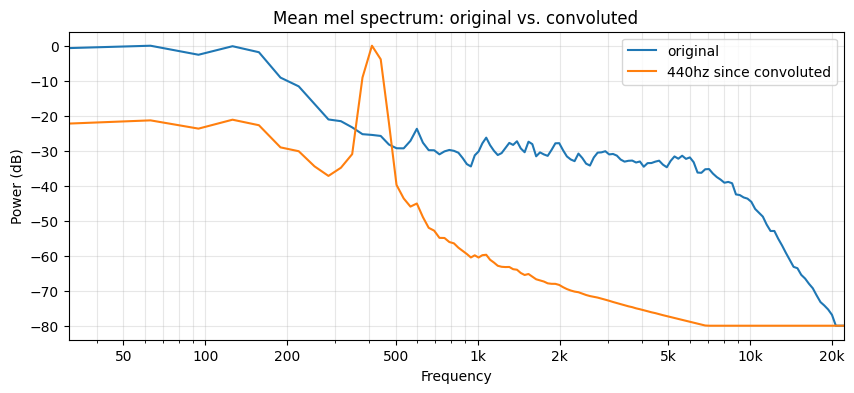

In [10]:
def mean_mel_db(sig, sr, n_mels=128, n_fft=2048, hop_length=512):
    S = librosa.feature.melspectrogram(
        y=sig, sr=sr, n_fft=n_fft, hop_length=hop_length,
        n_mels=n_mels, fmax=sr/2
    )
    return librosa.power_to_db(S.mean(axis=1), ref=np.max)

mel_freqs = librosa.mel_frequencies(n_mels=128, fmax=sr/2)

S_db     = mean_mel_db(y,     sr)
S_db_hpf = mean_mel_db(c, sr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mel_freqs, S_db,     label='original')
ax.plot(mel_freqs, S_db_hpf, label='440hz since convoluted')
ax.set(xlabel='Frequency', ylabel='Power (dB)',
       title='Mean mel spectrum: original vs. convoluted')
ax.set_xscale('log')

# explicit ticks at musically meaningful frequencies
ticks = [20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
ticks = [t for t in ticks if t <= sr/2]          # drop any above Nyquist
ax.set_xticks(ticks)

def hz_fmt(x, _):
    return f'{x/1000:g}k' if x >= 1000 else f'{x:g}'
ax.xaxis.set_major_formatter(FuncFormatter(hz_fmt))
ax.xaxis.set_minor_formatter(NullFormatter())    # suppress log minor-tick labels

ax.set_xlim(mel_freqs[mel_freqs > 0].min(), sr/2)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

1. From the observation, the power has drop down of the original signal
2. The 440Hz frequency component is prominent in the signal. In the sine audio wave, this is prevalent.

Let's try shortening the convolution window sine wave into 1000 samples.

In [11]:
sr = 44100          # sample rate (Hz)
duration = 1000/sr      # seconds
freq = 440.0        # Hz (A4)

t = np.linspace(0, duration, int(sr * duration), endpoint=False)
sine = np.sin(2 * np.pi * freq * t)

c = np.convolve(y, sine, mode='same')

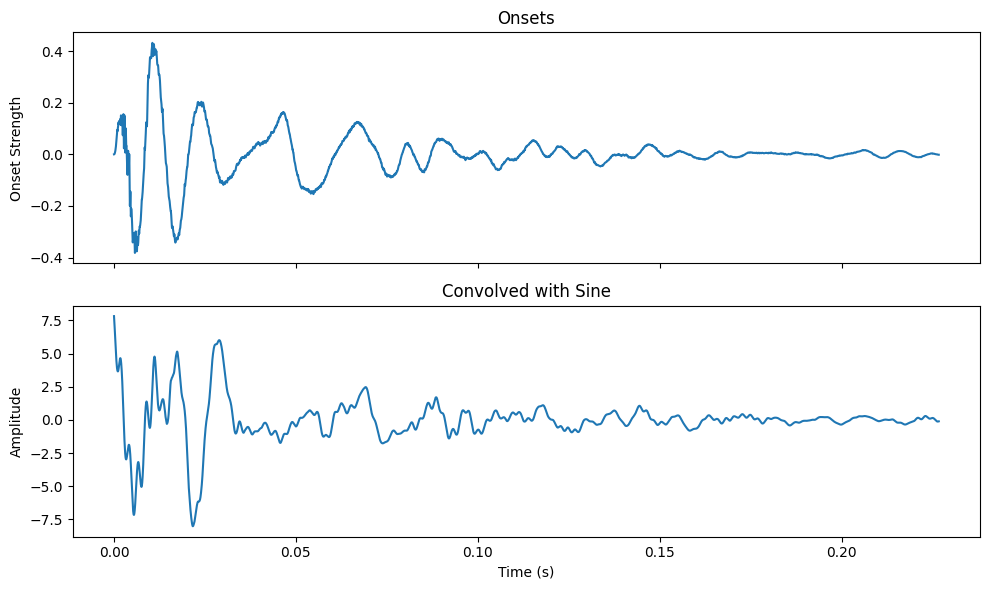

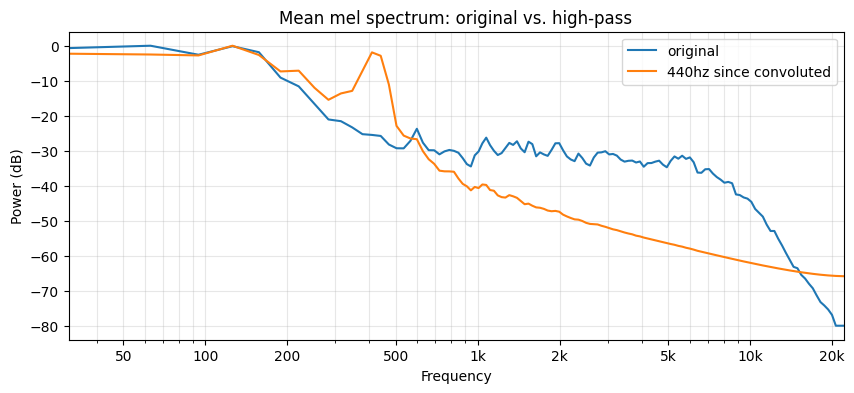

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
n_samples = 10000
ax1.plot(np.arange(n_samples) / sr, y[:n_samples])
ax1.set_ylabel("Onset Strength")
ax1.set_title("Onsets")

ax2.plot(np.arange(n_samples) / sr, c[:n_samples])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Convolved with Sine")

plt.tight_layout()
plt.show()

##############

S_db     = mean_mel_db(y,     sr)
S_db_hpf = mean_mel_db(c, sr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mel_freqs, S_db,     label='original')
ax.plot(mel_freqs, S_db_hpf, label='440hz since convoluted')
ax.set(xlabel='Frequency', ylabel='Power (dB)',
       title='Mean mel spectrum: original vs. high-pass')
ax.set_xscale('log')

# explicit ticks at musically meaningful frequencies
ticks = [20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
ticks = [t for t in ticks if t <= sr/2]          # drop any above Nyquist
ax.set_xticks(ticks)

def hz_fmt(x, _):
    return f'{x/1000:g}k' if x >= 1000 else f'{x:g}'
ax.xaxis.set_major_formatter(FuncFormatter(hz_fmt))
ax.xaxis.set_minor_formatter(NullFormatter())    # suppress log minor-tick labels

ax.set_xlim(mel_freqs[mel_freqs > 0].min(), sr/2)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

Audio(c, rate=sr)

1. Now it's clearly seen the properties of the sine wave has been dimished significantly.
2. In the convoluted sound, the charateristics of the sine wave sound is mildly prominent on onsets.

## Trying out average filter

- I want to find out the frequency response and waveform changes based on average convolution filter.
- For this, I will use [1/n 1/n ... 1/n] a n average filter where n is the length of the filter. This will help in smoothing out the signal and observing how it affects the sine wave characteristics.

In [13]:
N = 1000
avg_filter = np.ones(N) / N

c = np.convolve(y, avg_filter, mode='same')


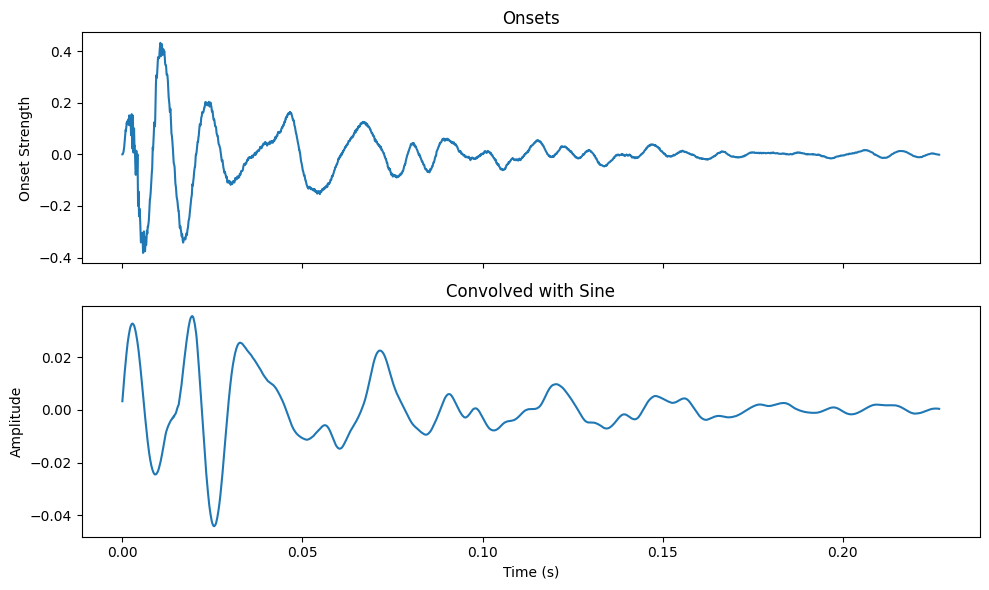

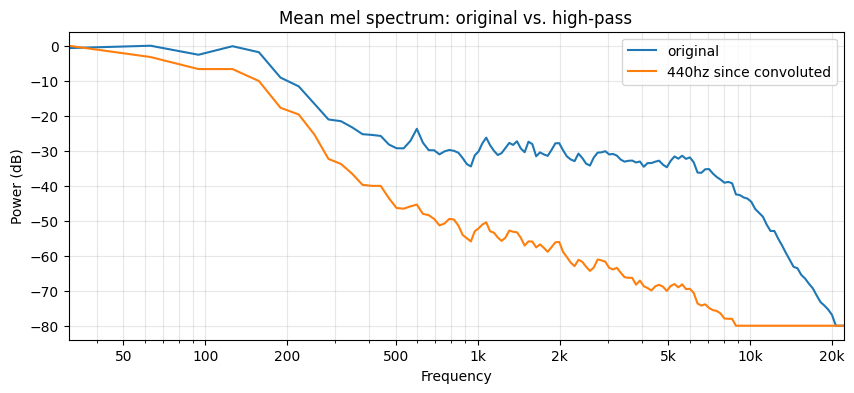

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
n_samples = 10000
ax1.plot(np.arange(n_samples) / sr, y[:n_samples])
ax1.set_ylabel("Onset Strength")
ax1.set_title("Onsets")

ax2.plot(np.arange(n_samples) / sr, c[:n_samples])
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Convolved with Sine")


plt.tight_layout()
plt.show()

##############

S_db     = mean_mel_db(y,     sr)
S_db_hpf = mean_mel_db(c, sr)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mel_freqs, S_db,     label='original')
ax.plot(mel_freqs, S_db_hpf, label='440hz since convoluted')
ax.set(xlabel='Frequency', ylabel='Power (dB)',
       title='Mean mel spectrum: original vs. high-pass')
ax.set_xscale('log')

# explicit ticks at musically meaningful frequencies
ticks = [20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000]
ticks = [t for t in ticks if t <= sr/2]          # drop any above Nyquist
ax.set_xticks(ticks)

def hz_fmt(x, _):
    return f'{x/1000:g}k' if x >= 1000 else f'{x:g}'
ax.xaxis.set_major_formatter(FuncFormatter(hz_fmt))
ax.xaxis.set_minor_formatter(NullFormatter())    # suppress log minor-tick labels

ax.set_xlim(mel_freqs[mel_freqs > 0].min(), sr/2)
ax.grid(True, which='both', alpha=0.3)
ax.legend()

Audio(c, rate=sr)

- The frequency spectrum shape is resembling the original signal while it's evident the higher frequncy power was smoothed further.
- The wave form clearly indicates the power drop effected only to snare drums which carry high frequency components, while the lower frequency components like bass and kick drums remain relatively unaffected.

Based on the results, The width of the filter window can clearly make and effect of the output signal to carry properties to the convoluted signal.

Next experiment
1. explain why the frequency drop happening
2. Experiment with changing the amplitude of the sine wave and observe what properties change.
2. experiment with a vocal signal as a filter